In [1]:
import pandas as pd
import numpy as np
import pickle
import keras
from sklearn.metrics import r2_score, mean_squared_error, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt # 그래프 그리는 라이브러리

In [2]:
import os

def make_input_data(df): 
    # 입력데이터 생성
    df_input1 = df.iloc[:PAST_STEP]
    df_input1 = df_input1[INPUT1_COL]
    input1 = np.array(df_input1)
    
    df_input2 = df.iloc[PAST_STEP:]
    df_output = df_input2[TARGET_COL]
    df_input2 = df_input2[INPUT2_COL]
    
    input2 = np.array(df_input2)
    output = np.array(df_output).flatten()
    
    
    input1 =  scaler_x.transform(input1) # 입력자료 1(관측) 데이터 스케일링
    input2 =  scaler_f.transform(input2) # 입력자료 2(예보) 데이터 스케일링

    input1 = input1.reshape(1, input1.shape[-2], input1.shape[-1])
    input2 = input2.reshape(1, input2.shape[-2], input2.shape[-1])
    
    return input1, input2, output
    
def HQCurve(waterlevel):
    # 수위로 유량을 구하는 곡선식 (23.11 ~ 부터 적용 )
    if waterlevel >= 0.54 and waterlevel <= 1.31 :
        return 40.769 * (waterlevel - 0.540) ** 1.728
    elif waterlevel > 1.31 and waterlevel <= 2.42 :
        return 13.779 * ( waterlevel - 0.040 ) ** 2.649
    else :
        return 22.778 * ( h - 0.400 ) ** 2.552
        
def QHCurve(flow):
    # 유량으로 수위를 구하는 곡선식 (23.11 ~ 부터 적용 )
    if flow >= HQCurve(0.54) and flow <= HQCurve(1.31) :
        return  0.540 + ( flow / 40.769 ) ** (1/1.728)
    elif flow > HQCurve(1.31) and flow <= HQCurve(2.42) :
        return 0.040 + ( flow / 13.779 ) ** (1/2.649)
    else :
        return 0.400 + ( flow / 22.778 ) ** (1/2.552)

def drawBothGraph(y_real_gn, y_pred_gn, y_real_dg, y_pred_dg, pred_type):
    # 궁내교 대곡교 예측 결과 통합 그래프
    # y_real : 관측, y_pred : 예측

    plt.figure(figsize=(15, 8))

    start = len(y_real_gn) - len(y_pred_gn)     # 보통 72-36=36
    
    plt.axvline(start-0.5, linestyle="--", linewidth=1, color="gray")
    #gn
    plt.plot(np.arange(len(y_real_gn)), y_real_gn, 'blue')
    plt.plot(np.arange(start, start + len(y_pred_gn)), y_pred_gn, 'orange')
    #dg
    plt.plot(np.arange(len(y_real_dg)), y_real_dg, 'green')
    plt.plot(np.arange(start, start + len(y_pred_dg)), y_pred_dg, 'coral')


    # plt.axis
    plt.ylim(1.45, 712.55)
    plt.legend([f'pred start', f'obs_gn', f'pred_gn', f'obs_dg', f'pred_dg'], loc='upper left')
    plt.title(f'Tancheon {pred_type} Prediction Result ')
    plt.xlabel('step')
    plt.ylabel(f'{pred_type}(m)')
    
    plt.tight_layout()
    plt.show()

def drawBothRainGraph(df, pred_type="rain"):
    plt.figure(figsize=(15, 5))

    col_gn = '궁내교_Ti'
    col_dg = '대곡교_Ti'

    rain_gn = df[col_gn].values
    rain_dg = df[col_dg].values

    x = np.arange(len(df))

    y_max = 22

    plt.figure(figsize=(15, 4))

    # bar 겹침 방지 (살짝 좌우 이동)
    plt.bar(x - 0.15, -rain_gn, width=0.3, color='skyblue', label='gn Ti')
    plt.bar(x + 0.15, -rain_dg, width=0.3, color='green', label='dg Ti')

    plt.axhline(0, color='black', linewidth=0.5)
    plt.xlabel('step')
    plt.ylabel('Ti (mm)')
    plt.ylim(-y_max, 0)
    plt.title('gn + dg Ti')
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

In [3]:
# 유량 예측 모델일 시 이 변수 사용
DG_OUTPUT_COL = ['서울시(대곡교)_Q']
GN_OUTPUT_COL = ['성남시(궁내교)_Q']
DG_WL_COL = '서울시(대곡교)_WL'
GN_WL_COL = '성남시(궁내교)_WL'
INPUT1_COL = [
                '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
                '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
                '궁내교_Ti', '대곡교_Ti', '성남시(궁내교)_Q', '서울시(대곡교)_Q' ]

# 수위 예측 모델일 시 이 변수 사용
# DG_OUTPUT_COL = ['서울시(대곡교)_WL']
# GN_OUTPUT_COL = ['성남시(궁내교)_WL']
# INPUT1_COL = [
#                 '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
#                 '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
#                 '궁내교_Ti', '대곡교_Ti', '성남시(궁내교)_WL', '서울시(대곡교)_WL' ]

INPUT2_COL = [
                '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
                '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
                '궁내교_Ti', '대곡교_Ti', 
            ]

testdata_dir = './testdata'


testdata_200802 = f'{testdata_dir}/36step/20200802.csv'
testdata_220712 = f'{testdata_dir}/36step/20220712_048.csv'
testdata_230711 = f'{testdata_dir}/36step/20230711_044.csv'
testdata_240723 = f'{testdata_dir}/36step/20240723.csv'
testdata_250716 = f'{testdata_dir}/36step/250716_1700.xlsx'
testdata_250814 = f'{testdata_dir}/36step/250814_0500.xlsx'

# testdata_200802 = f'{testdata_dir}/72step/20200802.csv'
# testdata_220712 = f'{testdata_dir}/72step/20220712_048.csv'
# testdata_230711 = f'{testdata_dir}/72step/20230711_044.csv'
# testdata_240723 = f'{testdata_dir}/72step/20240723.csv'
# testdata_250716 = f'{testdata_dir}/72step/250716_1700.xlsx'
# testdata_250814 = f'{testdata_dir}/72step/250814_0500.xlsx'

testdata_200802 = pd.read_csv(testdata_200802) 
testdata_220712 = pd.read_csv(testdata_220712) 
testdata_230711 = pd.read_csv(testdata_230711) 
testdata_240723 = pd.read_csv(testdata_240723) 
testdata_250716 = pd.read_excel(testdata_250716) # 250716 테스트 데이터 Dataframe
testdata_250814 = pd.read_excel(testdata_250814) # 250814 테스트 데이터 Dataframe

In [4]:
# PAST_STEP = 54 # 관측 데이터 사용량 (10분단위, 9시간, 54 STEP)
PAST_STEP = 36 # 관측 데이터 사용량 (10분단위, 6시간, 36 STEP)
FORECAST_STEP = 72 # 예보 데이터 사용량 ( 10분단위, 12시간, 72 STEP )
model = "flow"

In [5]:
# testdata_200802 = pd.read_csv(testdata_200802) 
# testdata_220712 = pd.read_csv(testdata_220712) 
# testdata_230711 = pd.read_csv(testdata_230711) 
# testdata_240723 = pd.read_csv(testdata_240723) 
# testdata_250716 = pd.read_excel(testdata_250716) # 250716 테스트 데이터 Dataframe
# testdata_250814 = pd.read_excel(testdata_250814) # 250814 테스트 데이터 Dataframe

data = testdata_250814

In [6]:
# -----------------------
# 1) 궁내교 예측 (gn)
# -----------------------
target_key = "gn"

TARGET_COL = DG_OUTPUT_COL if target_key == 'dg' else GN_OUTPUT_COL
WL_COL     = DG_WL_COL     if target_key == 'dg' else GN_WL_COL
Q_COL = DG_OUTPUT_COL if target_key == 'dg' else GN_OUTPUT_COL

dir_model  = f'./model_stage/model_{target_key}_{model}'
scalerfile = f'./model_stage/scaler_{target_key}_{model}.pkl'

with open(scalerfile, 'rb') as file:
    scaler_x = pickle.load(file)
    scaler_f = pickle.load(file)
    scaler_y = pickle.load(file)

model_gn = keras.models.load_model(dir_model)

input1, input2, output = make_input_data(data)

y_pred_gn = model_gn.predict([input1, input2], verbose=0)
y_pred_gn = scaler_y.inverse_transform(y_pred_gn.reshape(1, -1))[0]  # (72,)
y_real_gn = data[Q_COL].to_numpy().flatten()

In [7]:
# -----------------------
# 2) 대곡교 예측 (dg)
# -----------------------
target_key = "dg"

TARGET_COL = DG_OUTPUT_COL if target_key == 'dg' else GN_OUTPUT_COL
WL_COL     = DG_WL_COL     if target_key == 'dg' else GN_WL_COL
Q_COL = DG_OUTPUT_COL if target_key == 'dg' else GN_OUTPUT_COL

dir_model  = f'./model_stage/model_{target_key}_{model}'
scalerfile = f'./model_stage/scaler_{target_key}_{model}.pkl'

with open(scalerfile, 'rb') as file:
    scaler_x = pickle.load(file)
    scaler_f = pickle.load(file)
    scaler_y = pickle.load(file)

model_dg = keras.models.load_model(dir_model)

# input은 동일 data에서 뽑는 거라 재사용해도 되고(그대로 써도 됨)
input1, input2, output = make_input_data(data)

y_pred_dg = model_dg.predict([input1, input2], verbose=0)
y_pred_dg = scaler_y.inverse_transform(y_pred_dg.reshape(1, -1))[0]  # (72,)
y_real_dg = data[Q_COL].to_numpy().flatten()

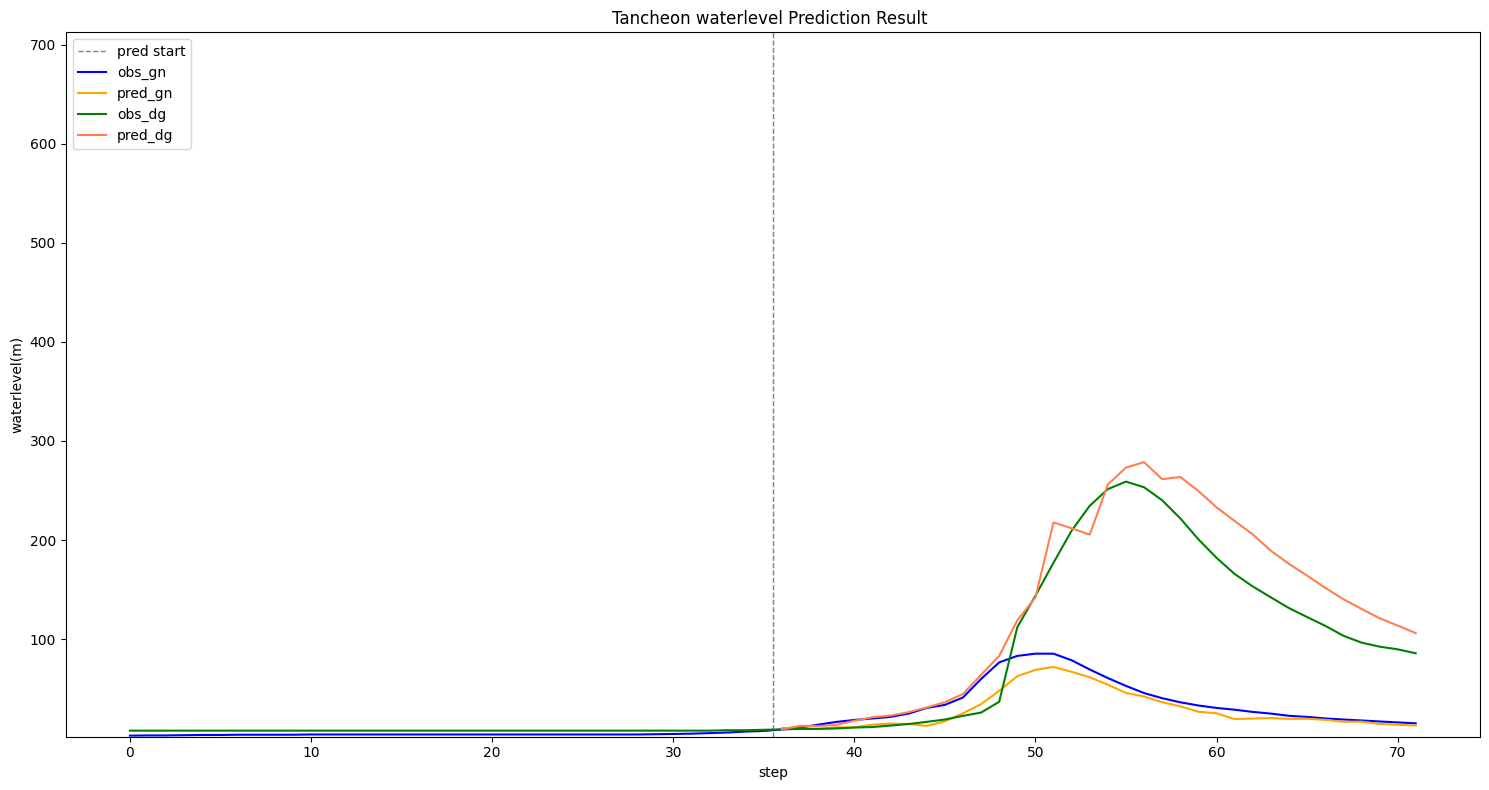

In [8]:
# -----------------------
# 3) 한 장에 그리기
# -----------------------
#수위
drawBothGraph(y_real_gn, y_pred_gn, y_real_dg, y_pred_dg, pred_type="waterlevel")

In [9]:
# 강우
# drawBothRainGraph(data)